In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_regression
from sklearn.feature_selection import SelectPercentile
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.model_selection import cross_val_score

In [17]:
student=pd.read_csv("Student_Performance.csv")

In [18]:
student.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [19]:
student.shape

(10000, 6)

In [20]:
student.isna().sum()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

In [21]:
student['Performance Index'].min()

10.0

In [22]:
student['Performance Index'].max()

100.0

In [23]:
student.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [24]:
student['Extracurricular Activities']=np.where(student['Extracurricular Activities'] == "Yes",1,0)

In [25]:
student.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0


In [26]:
 student.corr()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
Hours Studied,1.000000,-0.012390,0.003873,0.001245,0.017463,0.373730
Previous Scores,-0.012390,1.000000,0.008369,0.005944,0.007888,0.915189
Extracurricular Activities,0.003873,0.008369,1.000000,-0.023284,0.013103,0.024525
Sleep Hours,0.001245,0.005944,-0.023284,1.000000,0.003990,0.048106
Sample Question Papers Practiced,0.017463,0.007888,0.013103,0.003990,1.000000,0.043268
Performance Index,0.373730,0.915189,0.024525,0.048106,0.043268,1.000000


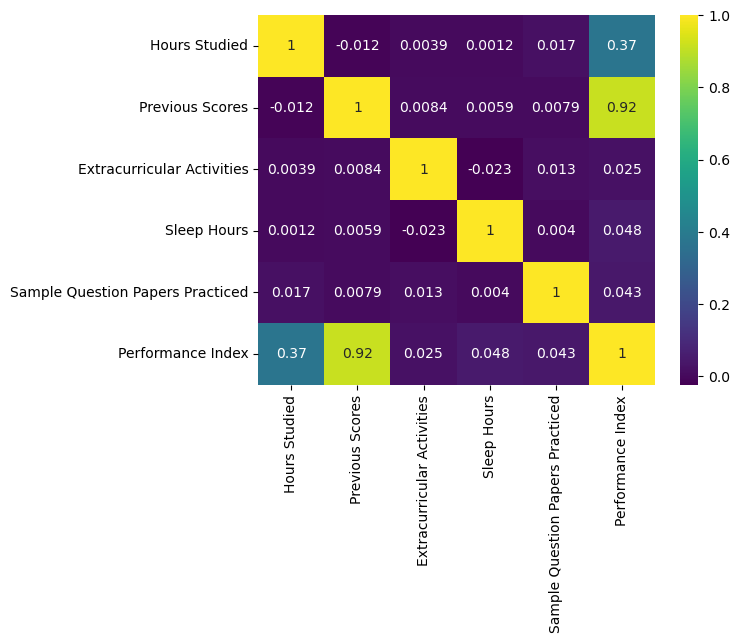

In [32]:
sns.heatmap(student.corr(),annot=True,cmap='viridis')
plt.show()

In [37]:
x_train,x_test,y_train,y_test=train_test_split(student.drop(labels=['Performance Index'],axis=1),
                                               student['Performance Index'],
                                               test_size=0.3,
                                               random_state=0)

In [38]:
x_train.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
7681,9,60,0,4,5
9031,8,43,0,5,5
3691,5,74,1,4,6
202,9,52,0,5,9
5625,8,57,0,5,4


In [41]:
mutual_info=mutual_info_regression(x_train,y_train)
mutual_info

array([0.13820293, 0.94987729, 0.        , 0.00522418, 0.        ])

In [43]:
mutual_info=pd.Series(mutual_info)
mutual_info.index=x_train.columns
mutual_info.sort_values(ascending=False)

Previous Scores                     0.949877
Hours Studied                       0.138203
Sleep Hours                         0.005224
Extracurricular Activities          0.000000
Sample Question Papers Practiced    0.000000
dtype: float64

<Axes: >

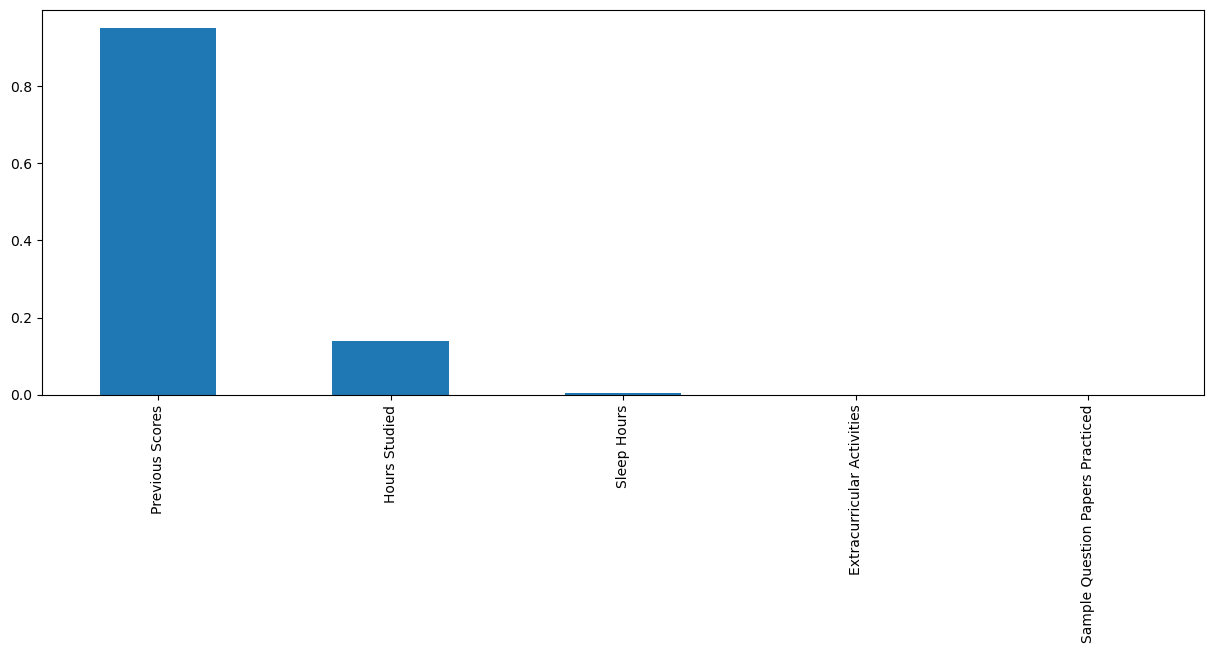

In [44]:
mutual_info.sort_values(ascending=False).plot.bar(figsize=(15,5))

In [54]:
selected_top_performances=SelectPercentile(mutual_info_regression,percentile=40)
selected_top_performances.fit(x_train,y_train)

,score_func,<function mut...00196990A9EE0>
,percentile,40


In [57]:
selected_top_performances.get_support()

array([ True,  True, False, False, False])

In [58]:
x_train.columns[selected_top_performances.get_support()]

Index(['Hours Studied', 'Previous Scores'], dtype='object')

In [62]:
x_train.drop(['Sleep Hours','Extracurricular Activities','Sample Question Papers Practiced'],inplace=True,axis=1)

In [63]:
x_train.head()

,Hours Studied,Previous Scores
7681,9,60
9031,8,43
3691,5,74
202,9,52
5625,8,57


In [64]:
x_test.drop(['Sleep Hours','Extracurricular Activities','Sample Question Papers Practiced'],inplace=True,axis=1)

In [65]:
x_test.head()

,Hours Studied,Previous Scores
9394,4,67
898,8,60
2398,6,90
5906,1,51
2343,2,90


In [67]:
model=LinearRegression()

In [68]:
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [69]:
y_preds=model.predict(x_train)

In [73]:
mean_squared_error(y_train, y_preds)

5.222394440143651

In [78]:
rmse=np.sqrt(mean_squared_error(y_train, y_preds))
rmse

np.float64(2.285255880671495)

In [83]:
r2_score(y_train, y_preds)

0.9859839329269132

In [74]:
y_predicts=model.predict(x_test)

In [76]:
mean_squared_error(y_test,y_predicts)

5.197114973058084

In [79]:
rmse1=np.sqrt(mean_squared_error(y_test, y_predicts))
rmse1

np.float64(2.2797181784286593)

In [82]:
r2 = r2_score(y_test, y_predicts)
r2

0.9855989148980643

In [85]:
scores = cross_val_score(model, x_train, y_train, cv=5, scoring='r2')

In [86]:
print(scores)
print(scores.mean())

[0.98630254 0.98501044 0.98627317 0.98674702 0.98542013]
0.9859506603227279


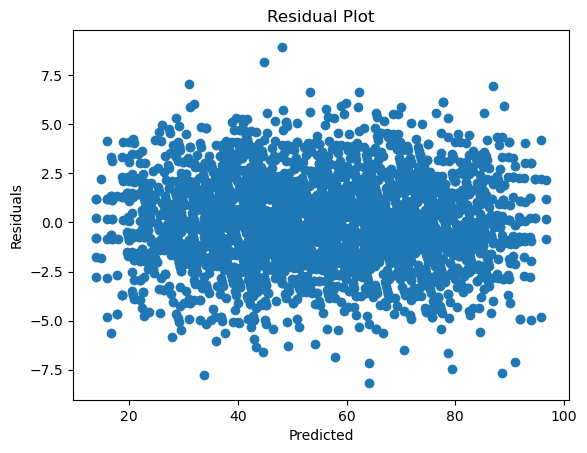

In [87]:
import matplotlib.pyplot as plt

residuals = y_test - model.predict(x_test)

plt.scatter(model.predict(x_test), residuals)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [88]:
import pandas as pd

coefficients = pd.DataFrame({
    "Feature": x_train.columns,
    "Coefficient": model.coef_
})

print(coefficients.sort_values(by="Coefficient", ascending=False))

           Feature  Coefficient
0    Hours Studied     2.854335
1  Previous Scores     1.020346
